<a href="https://colab.research.google.com/github/Tsaraban/Tsaraban_Capstone_Project/blob/main/GCN_vs_RAG_for_DDI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Step 1: SMILES Extraction**
This step runs a second iterparse pass through the DrugBank dataset to extract each drug's SMILES string, which is a compact text representation of the drug's molecular structure. SMILES functions as a “chemical spelling” that encodes how the atoms in the molecule are arranged. After retrieving these SMILES strings, the system attaches them to the existing drug-interaction records. As a result, every drug pair in the dataset is enriched with the chemical structure information for both drugs. This ensures that each interaction entry contains not only the interaction data itself but also the structural descriptions needed for later chemistry based modelling.
The retrived dataset drugbank 'ddi_interactions.csv' has drugs paired and tells us the interaction, but no molecular structure of the drugs. But, the GCN model needs modecular graph for each drug, and that required this SMILES step which helped the drugs to be paired with chemistry spelling where

In [ ]:
# Mounting google drive to access colab and datasets

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# lxml is required for iterparse; pandas/tqdm are for tabular output and progress visibility over what will be a long-running loop (500k+ drugs).
!pip install -q lxml pandas tqdm


BASE_PATH = '/content/drive/MyDrive/4th year Coursework/Capstone Project'

import os
os.makedirs(BASE_PATH, exist_ok=True)

#paths for excisting xml file, already produced csv file
DRUGBANK_XML_PATH = f'{BASE_PATH}/full_database.xml'
INTERACTIONS_CSV  = f'{BASE_PATH}/interactions.csv'

#output file and merged file
SMILES_CSV_PATH   = f'{BASE_PATH}/drug_smiles.csv'
MERGED_CSV_PATH   = f'{BASE_PATH}/ddi_interactions_with_smiles.csv'

In [ ]:
# Iterparse pass over DrugBank XML for DrugBank ID + SMILES
# Created this code with the help and guildine from https://docs.drugbank.com/xml/#drugs
# Extract DrugBank ID + SMILES via iterparse

from lxml import etree
import pandas as pd
from tqdm import tqdm

NS = '{http://www.drugbank.ca}'

"""Streams the DrugBank XML using iterparse so the 1.77 GB file can be processed without loading it into memory.
For each <drug> entry, it extracts the primary DrugBank ID and the calculated SMILES string.
The script writes results in small chunks to avoid losing progress if the Colab session disconnects,
following the same incremental-write pattern used in the earlier interaction-extraction script."""

def extract_smiles(xml_path, chunk_flush=100_000, out_path=SMILES_CSV_PATH):
    rows, first_write = [], True
    n_seen = n_with_smiles = n_written = 0

    context = etree.iterparse(xml_path, events=('end',), tag=f'{NS}drug') #wait for 'end'

    for _, elem in tqdm(context, desc='Parsing drugs for SMILES'):
        n_seen += 1


        # Only the one marked primary="true" is guaranteed to match the IDs used in the csv file

        drug_id = None
        for id_elem in elem.findall(f'{NS}drugbank-id'):
            if id_elem.get('primary') == 'true':
                drug_id = id_elem.text
                break
        if drug_id is None:
            id_elem = elem.find(f'{NS}drugbank-id')
            drug_id = id_elem.text if id_elem is not None else None

        smiles = None
        calc_props = elem.find(f'{NS}calculated-properties')
        if calc_props is not None:
            for prop in calc_props.findall(f'{NS}property'):
                kind = prop.find(f'{NS}kind')
                if kind is not None and kind.text == 'SMILES':
                    value = prop.find(f'{NS}value')
                    if value is not None:
                        smiles = value.text
                    break

        if drug_id is not None and smiles is not None:
            rows.append({'drug_id': drug_id, 'smiles': smiles})
            n_with_smiles += 1

        if len(rows) >= chunk_flush:
            pd.DataFrame(rows).to_csv(out_path, mode='w' if first_write else 'a',
                                       header=first_write, index=False)
            first_write = False
            n_written += len(rows)
            rows = []

        # memory-safety: clear processed element and drop earlier siblings
        """CRITICAL for iterparse memory safety: clear the element and
        remove now-empty preceding siblings from the tree. Without this,
        lxml keeps every already-processed <drug> in memory as part of
        the tree, and eventually exhaust Colab's RAM on a file
        this size."""

        elem.clear()
        while elem.getprevious() is not None:
            del elem.getparent()[0]

    if rows:
        pd.DataFrame(rows).to_csv(out_path, mode='w' if first_write else 'a',
                                   header=first_write, index=False)
        n_written += len(rows)

    print(f'Drugs seen: {n_seen}, with SMILES: {n_with_smiles}, rows written: {n_written}')
    return out_path

extract_smiles(DRUGBANK_XML_PATH)

Parsing drugs for SMILES: 1014340it [00:50, 20174.57it/s]


Drugs seen: 1014340, with SMILES: 14619, rows written: 14619


'/content/drive/MyDrive/4th year Coursework/Capstone Project/drug_smiles.csv'

In [ ]:
# Merging SMILES onto the interactions CSV
# Droping rows that are missing either SMILES
 """A left-merge, twice: each interaction row references TWO drugs, so the SMILES lookup table has to be
joined on twice, (once per side of the pair) to attach both structures
to the same row."""

interactions_df = pd.read_csv(INTERACTIONS_CSV)
smiles_df = pd.read_csv(SMILES_CSV_PATH).drop_duplicates(subset='drug_id')

print(f'Interactions rows before merge: {len(interactions_df)}')
print(f'Unique drugs with SMILES: {len(smiles_df)}')

merged = interactions_df.merge(
    smiles_df.rename(columns={'smiles': 'smiles_drug'}),
    on='drug_id', how='left'
)
merged = merged.merge(
    smiles_df.rename(columns={'drug_id': 'interacting_drug_id', 'smiles': 'smiles_interacting_drug'}),
    on='interacting_drug_id', how='left'
)

before = len(merged)
merged = merged.dropna(subset=['smiles_drug', 'smiles_interacting_drug']).reset_index(drop=True)
print(f'Dropped {before - len(merged)} rows missing one or both SMILES ({len(merged)} remain)')

merged.to_csv(MERGED_CSV_PATH, index=False)
print(f'Saved: {MERGED_CSV_PATH}')
merged.head()

Interactions rows before merge: 2911156
Unique drugs with SMILES: 14619
Dropped 547422 rows missing one or both SMILES (2363734 remain)
Saved: /content/drive/MyDrive/4th year Coursework/Capstone Project/ddi_interactions_with_smiles.csv


,drug_id,drug_name,interacting_drug_id,interacting_drug_name,description,smiles_drug,smiles_interacting_drug
0,DB00006,Bivalirudin,DB06605,Apixaban,Apixaban may increase the anticoagulant activi...,CC[C@H](C)[C@H](NC(=O)[C@H](CCC(O)=O)NC(=O)[C@...,COC1=CC=C(C=C1)N1N=C(C(N)=O)C2=C1C(=O)N(CC2)C1...
1,DB00006,Bivalirudin,DB06695,Dabigatran etexilate,Dabigatran etexilate may increase the anticoag...,CC[C@H](C)[C@H](NC(=O)[C@H](CCC(O)=O)NC(=O)[C@...,CCCCCCOC(=O)\N=C(\N)C1=CC=C(NCC2=NC3=C(C=CC(=C...
2,DB00006,Bivalirudin,DB01254,Dasatinib,The risk or severity of bleeding and hemorrhag...,CC[C@H](C)[C@H](NC(=O)[C@H](CCC(O)=O)NC(=O)[C@...,CC1=NC(NC2=NC=C(S2)C(=O)NC2=C(C)C=CC=C2Cl)=CC(...
3,DB00006,Bivalirudin,DB01609,Deferasirox,The risk or severity of gastrointestinal bleed...,CC[C@H](C)[C@H](NC(=O)[C@H](CCC(O)=O)NC(=O)[C@...,OC(=O)C1=CC=C(C=C1)N1N=C(N=C1C1=CC=CC=C1O)C1=C...
4,DB00006,Bivalirudin,DB01586,Ursodeoxycholic acid,The risk or severity of bleeding and bruising ...,CC[C@H](C)[C@H](NC(=O)[C@H](CCC(O)=O)NC(=O)[C@...,[H][C@@]1(CC[C@@]2([H])[C@]3([H])[C@@H](O)C[C@...


# **Step 2: Dataset Construction**
DrugBank only lists interactions that actually occur, so it contains only positive examples. A classifier needs both positives and negatives; otherwise it would learn to always predict “interaction.” This step removes duplicate interaction pairs and then creates an equal number of non-interacting drug pairs, turning the task into a proper binary classification problem. It then shuffles the data and uses stratified splitting to produce balanced train, validation, and test sets.

Also, binary classification a 0/1 label, and an 80:10:10 train/validation/test split.

In [ ]:
!pip install -q pandas numpy scikit-learn tqdm

from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/4th year Coursework/Capstone Project'
MERGED_CSV_PATH = f'{BASE_PATH}/ddi_interactions_with_smiles.csv'
TRAIN_CSV = f'{BASE_PATH}/ddi_train.csv'
VAL_CSV   = f'{BASE_PATH}/ddi_val.csv'
TEST_CSV  = f'{BASE_PATH}/ddi_test.csv'

RANDOM_SEED = 42

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Deduplicate directed pairs -> undirected pairs, build positive set

"""Sorting each drug pair before creating the key ensures that “A interacts with B” and “B interacts with A” are treated as the same interaction.
DrugBank often lists both directions separately, but by sorting the pair into a consistent order,
both entries collapse into one record. This lets drop_duplicates correctly remove duplicates instead of treating them as two different interactions."""

import pandas as pd
import numpy as np
import random
from sklearn.model_selection import train_test_split

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

df = pd.read_csv(MERGED_CSV_PATH)

# Canonical undirected pair key so A-B and B-A collapse to one record
def make_pair_key(a, b):
    return tuple(sorted((a, b)))

df['pair_key'] = df.apply(lambda r: make_pair_key(r['drug_id'], r['interacting_drug_id']), axis=1)

# Deduplicate: keep first occurrence per unique undirected pair, keep SMILES + one description
dedup = df.drop_duplicates(subset='pair_key').reset_index(drop=True)
print(f'Rows before dedup: {len(df)}, after collapsing directed duplicates: {len(dedup)}')

# Build lookup of drug_id -> smiles (from either column) for negative sampling
id_to_smiles = {}
for _, r in dedup.iterrows():
    id_to_smiles[r['drug_id']] = r['smiles_drug']
    id_to_smiles[r['interacting_drug_id']] = r['smiles_interacting_drug']

all_drug_ids = list(id_to_smiles.keys())
positive_pairs = set(dedup['pair_key'])

print(f'Unique drugs available for pairing: {len(all_drug_ids)}')
print(f'Documented (positive) pairs: {len(positive_pairs)}')

Rows before dedup: 2363734, after collapsing directed duplicates: 1181867
Unique drugs available for pairing: 3701
Documented (positive) pairs: 1181867


In [ ]:
# CELL 3 — Negative sampling at 1:1 ratio (random pairs not in documented set)
def sample_negative_pairs(n_needed, positive_pairs, drug_ids, max_attempts_factor=20):
    negatives = set()
    attempts = 0
    max_attempts = n_needed * max_attempts_factor
    while len(negatives) < n_needed and attempts < max_attempts:
        a, b = random.sample(drug_ids, 2)
        key = make_pair_key(a, b)
        if key not in positive_pairs and key not in negatives:
            negatives.add(key)
        attempts += 1
    if len(negatives) < n_needed:
        print(f'Warning: only sampled {len(negatives)}/{n_needed} negatives after {attempts} attempts')
    return list(negatives)

n_pos = len(positive_pairs)
negative_pairs = sample_negative_pairs(n_pos, positive_pairs, all_drug_ids)

pos_rows = [{'drug_id': k[0], 'interacting_drug_id': k[1],
             'smiles_drug': id_to_smiles[k[0]], 'smiles_interacting_drug': id_to_smiles[k[1]],
             'label': 1} for k in positive_pairs]
neg_rows = [{'drug_id': k[0], 'interacting_drug_id': k[1],
             'smiles_drug': id_to_smiles[k[0]], 'smiles_interacting_drug': id_to_smiles[k[1]],
             'label': 0} for k in negative_pairs]

dataset_df = pd.DataFrame(pos_rows + neg_rows).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
print(f'Final dataset: {len(dataset_df)} rows | positives: {dataset_df.label.sum()}, negatives: {(dataset_df.label==0).sum()}')

Final dataset: 2363734 rows | positives: 1181867, negatives: 1181867


In [ ]:
# CELL 4 — Stratified 80:10:10 split, save to Drive
#scikit‑learn can only split data into two parts at a time, the script first makes an 80/20 split, then splits that 20% in half to get the final 80:10:10 ratio.
"""Stratification is applied in both steps to keep the positive/negative balance the same in the training, validation, and test sets. Without stratification,
random chance could the class ratio in the smaller subsets, making accuracy and other metrics harder to compare fairly across splits."""

train_df, temp_df = train_test_split(
    dataset_df, test_size=0.20, stratify=dataset_df['label'], random_state=RANDOM_SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['label'], random_state=RANDOM_SEED
)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
for name, split in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f'  {name} label balance:\n{split.label.value_counts(normalize=True)}')

train_df.to_csv(TRAIN_CSV, index=False)
val_df.to_csv(VAL_CSV, index=False)
test_df.to_csv(TEST_CSV, index=False)
print('Saved train/val/test CSVs to Drive.')

Train: 1890987 | Val: 236373 | Test: 236374
  train label balance:
label
1    0.5
0    0.5
Name: proportion, dtype: float64
  val label balance:
label
0    0.500002
1    0.499998
Name: proportion, dtype: float64
  test label balance:
label
0    0.5
1    0.5
Name: proportion, dtype: float64
Saved train/val/test CSVs to Drive.


# **Step 3 — Molecular graph construction (RDKit → PyTorch Geometric)**


This step turns each drug's SMILES string into a graph that a GCN can actually use. SMILES is just text, but a GCN needs atoms, bonds, and their features represented as tensors. This step turns each drug's chemical code into a graph: atoms become dots (nodes), bonds become lines connecting them (edges), and each dot/line gets a few basic facts attached (like what element it is, or whether it's part of a ring). This turns chemistry into a shape a model can actually learn from. RDKit converts each SMILES into a molecule, the script extracts standard atom and bond features, and then builds a PyTorch Geometric graph object. Each drug pair is packaged as two graphs plus a label inside a custom Dataset, with a special collate function that can batch graphs of different sizes. This is what allows the GCN to learn structural patterns that simple fingerprints cannot capture.

In [ ]:

!pip install -q torch torch-geometric rdkit pandas tqdm


VAL_CSV   = f'{BASE_PATH}/ddi_val.csv'
TEST_CSV  = f'{BASE_PATH}/ddi_test.csv'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 74.7 MB/s eta 0:00:00


In [ ]:
SMILES -> PyG Data object
import torch
from torch_geometric.data import Data, Dataset
from rdkit import Chem
import pandas as pd

"""A fixed mapping is used because the GCN needs bond types expressed as numbers, not RDKit’s internal bond‑type objects.
Each common bond type is assigned a small integer code, and any rare or unusual bond type is safely given a fallback code instead of causing an error.
This ensures every bond can be represented consistently during graph construction."""

BOND_TYPES = {
    Chem.BondType.SINGLE: 0,
    Chem.BondType.DOUBLE: 1,
    Chem.BondType.TRIPLE: 2,
    Chem.BondType.AROMATIC: 3,
}

"""Each atom is described using six features that capture what it is, how it’s charged, how many neighbours it has, how many hydrogens
it carries, and whether it sits in a ring or aromatic structure.
Together, these features give a compact but chemically meaningful picture of the atom’s local environment."""

def atom_features(atom):
    return [
        atom.GetAtomicNum(),
        atom.GetFormalCharge(),
        atom.GetDegree(),
        atom.GetTotalNumHs(),
        int(atom.IsInRing()),
        int(atom.GetIsAromatic()),
    ]

def bond_features(bond):
    return [
        BOND_TYPES.get(bond.GetBondType(), 4), #Two features per bond: bond order/type, and ring membership
        int(bond.IsInRing()),
    ]

def smiles_to_graph(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    x = torch.tensor([atom_features(a) for a in mol.GetAtoms()], dtype=torch.float)

    edge_index, edge_attr = [], []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        feat = bond_features(bond)
        # undirected graph -> add both directions
        edge_index += [[i, j], [j, i]]
        edge_attr += [feat, feat]

    if len(edge_index) == 0:  # single-atom molecule edge case
        edge_index = torch.empty((2, 0), dtype=torch.long)
        edge_attr = torch.empty((0, 2), dtype=torch.float)
    else:
        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr)

In [ ]:
Paired-graph Dataset + custom collate
from torch.utils.data import Dataset as TorchDataset
from torch_geometric.data import Batch

class DDIPairDataset(TorchDataset):
    """
    Wraps a split CSV (drug_id, interacting_drug_id, smiles_drug,
    smiles_interacting_drug, label). Caches molecular graphs by SMILES
    so repeated drugs aren't reprocessed with RDKit.
    """
    def __init__(self, csv_path):
        self.df = pd.read_csv(csv_path).reset_index(drop=True)
        self._graph_cache = {}
        # Pre-filter rows whose SMILES fail to parse in RDKit
        valid_mask = []
        for _, row in self.df.iterrows():
            g1 = self._get_graph(row['smiles_drug'])
            g2 = self._get_graph(row['smiles_interacting_drug'])
            valid_mask.append(g1 is not None and g2 is not None)
        dropped = (~pd.Series(valid_mask)).sum()
        if dropped:
            print(f'Dropping {dropped} rows with unparseable SMILES from {csv_path}')
        self.df = self.df[pd.Series(valid_mask)].reset_index(drop=True)

    def _get_graph(self, smiles):
        if smiles not in self._graph_cache:
            self._graph_cache[smiles] = smiles_to_graph(smiles)
        return self._graph_cache[smiles]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        g1 = self._get_graph(row['smiles_drug'])
        g2 = self._get_graph(row['smiles_interacting_drug'])
        label = torch.tensor(row['label'], dtype=torch.float)
        return g1, g2, label

def pair_collate(batch):
    g1_list, g2_list, labels = zip(*batch)
    batch1 = Batch.from_data_list(list(g1_list))
    batch2 = Batch.from_data_list(list(g2_list))
    labels = torch.stack(labels)
    return batch1, batch2, labels

train_dataset = DDIPairDataset(TRAIN_CSV)
val_dataset   = DDIPairDataset(VAL_CSV)
test_dataset  = DDIPairDataset(TEST_CSV)
print(f'Train/Val/Test graph-pair sizes: {len(train_dataset)}/{len(val_dataset)}/{len(test_dataset)}')

[11:00:16] Unusual charge on atom 0 number of radical electrons set to zero
[11:00:17] SMILES Parse Error: syntax error while parsing: OC1=CC=CC(=C1)C-1=C2\CCC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC(O)=CC=C1)C1=CC(O)=CC=C1)\C1=CC(O)=CC=C1
[11:00:17] SMILES Parse Error: check for mistakes around position 76:
[11:00:17] C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC(O)=CC=C1)C
[11:00:17] ~~~~~~~~~~~~~~~~~~~~^
[11:00:17] SMILES Parse Error: extra open parentheses while parsing: OC1=CC=CC(=C1)C-1=C2\CCC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC(O)=CC=C1)C1=CC(O)=CC=C1)\C1=CC(O)=CC=C1
[11:00:17] SMILES Parse Error: check for mistakes around position 32:
[11:00:17] C1)C-1=C2\CCC(=N2)\C(=C2/N\C(\C=C2)=C(/C2
[11:00:17] ~~~~~~~~~~~~~~~~~~~~^
[11:00:17] SMILES Parse Error: extra open parentheses while parsing: OC1=CC=CC(=C1)C-1=C2\CCC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC(O)=CC=C1)C1=CC(O)=CC=C1)\C1=CC(O)=CC=C1
[11:00:17] SMILES Parse Error: check 

Dropping 627 rows with unparseable SMILES from /content/drive/MyDrive/4th year Coursework/Capstone Project/ddi_train.csv


[11:01:27] SMILES Parse Error: syntax error while parsing: OC1=CC=CC(=C1)C-1=C2\CCC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC(O)=CC=C1)C1=CC(O)=CC=C1)\C1=CC(O)=CC=C1
[11:01:27] SMILES Parse Error: check for mistakes around position 76:
[11:01:27] C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC(O)=CC=C1)C
[11:01:27] ~~~~~~~~~~~~~~~~~~~~^
[11:01:27] SMILES Parse Error: extra open parentheses while parsing: OC1=CC=CC(=C1)C-1=C2\CCC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC(O)=CC=C1)C1=CC(O)=CC=C1)\C1=CC(O)=CC=C1
[11:01:27] SMILES Parse Error: check for mistakes around position 32:
[11:01:27] C1)C-1=C2\CCC(=N2)\C(=C2/N\C(\C=C2)=C(/C2
[11:01:27] ~~~~~~~~~~~~~~~~~~~~^
[11:01:27] SMILES Parse Error: extra open parentheses while parsing: OC1=CC=CC(=C1)C-1=C2\CCC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC(O)=CC=C1)C1=CC(O)=CC=C1)\C1=CC(O)=CC=C1
[11:01:27] SMILES Parse Error: check for mistakes around position 49:
[11:01:27] )\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=

Dropping 75 rows with unparseable SMILES from /content/drive/MyDrive/4th year Coursework/Capstone Project/ddi_val.csv


[11:01:37] SMILES Parse Error: syntax error while parsing: OC1=CC=CC(=C1)C-1=C2\CCC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC(O)=CC=C1)C1=CC(O)=CC=C1)\C1=CC(O)=CC=C1
[11:01:37] SMILES Parse Error: check for mistakes around position 76:
[11:01:37] C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC(O)=CC=C1)C
[11:01:37] ~~~~~~~~~~~~~~~~~~~~^
[11:01:37] SMILES Parse Error: extra open parentheses while parsing: OC1=CC=CC(=C1)C-1=C2\CCC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC(O)=CC=C1)C1=CC(O)=CC=C1)\C1=CC(O)=CC=C1
[11:01:37] SMILES Parse Error: check for mistakes around position 32:
[11:01:37] C1)C-1=C2\CCC(=N2)\C(=C2/N\C(\C=C2)=C(/C2
[11:01:37] ~~~~~~~~~~~~~~~~~~~~^
[11:01:37] SMILES Parse Error: extra open parentheses while parsing: OC1=CC=CC(=C1)C-1=C2\CCC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC(O)=CC=C1)C1=CC(O)=CC=C1)\C1=CC(O)=CC=C1
[11:01:37] SMILES Parse Error: check for mistakes around position 49:
[11:01:37] )\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=

Dropping 63 rows with unparseable SMILES from /content/drive/MyDrive/4th year Coursework/Capstone Project/ddi_test.csv
Train/Val/Test graph-pair sizes: 1890360/236298/236311


# **Step 4 — GCN model & training**

This step builds and trains the Siamese GCN model. The structure-based part of the dissertation. Unlike the traditional models or RAG approaches, the GCN learns molecular structure directly from graphs. Each drug graph is encoded using the same GCN (shared weights), pooled into a fixed-length vector, and then the two drug embeddings are concatenated and classified by a small MLP. Three GCN layers let each atom gather information from its neighbourhood, and early stopping ensures the final model is the one that generalises best rather than the last epoch. This is the core structural-learning model used in Chapter 4.

This is where the first model actually learns something. It looks at each drug's molecule-graph, learns to summarise it as a list of numbers, then compares the two drugs' summaries to guess whether they interact. It practices on the training pile, checks itself against the validation pile after every round, and automatically stops once it stops improving — so it doesn't waste time or overlearn.

In [ ]:
!pip install -q torch torch-geometric matplotlib

from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/4th year Coursework/Capstone Project'
GCN_WEIGHTS_PATH = f'{BASE_PATH}/gcn_best_weights.pt'
GCN_LOSS_PLOT_PATH = f'{BASE_PATH}/gcn_loss_curves.png'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda


In [ ]:

"""Three GCN layers are used because each layer lets information spread one bond farther through the molecule. With three layers,
an atom ends up “seeing” its neighbourhood up to three bonds away, which is usually enough to capture important functional groups.
The layer widths increase (64 → 128 → 128) so the model can learn richer features as it goes deeper.
Keeping the network shallow also avoids over‑smoothing, where very deep GCNs make all atoms blur into nearly the same representation."""

import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool
from torch.utils.data import DataLoader

NODE_FEAT_DIM = 6  # atomic number, formal charge, degree, num H, is-in-ring, aromatic

class GCNEncoder(nn.Module):
    def __init__(self, in_dim=NODE_FEAT_DIM):
        super().__init__()
        self.conv1 = GCNConv(in_dim, 64)
        self.conv2 = GCNConv(64, 128)
        self.conv3 = GCNConv(128, 128)

    def forward(self, x, edge_index, batch):
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = F.relu(self.conv3(x, edge_index))
        x = global_mean_pool(x, batch)  # -> [num_graphs, 128]
        return x

#siamese GCN: shared encoder for both drug
#Siamese GCN: the SAME GCNEncoder instance (shared weights) processes both drugs in a pair, one at a time, so both embeddings live in the
#same learned space before being compared/combine.

class DDIGCN(nn.Module):

    def __init__(self, dropout=0.3):
        super().__init__()
        self.encoder = GCNEncoder()
        self.fc1 = nn.Linear(256, 128)
        self.fc2 = nn.Linear(128, 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, batch1, batch2):
        emb1 = self.encoder(batch1.x, batch1.edge_index, batch1.batch)  # [B,128]
        emb2 = self.encoder(batch2.x, batch2.edge_index, batch2.batch)  # [B,128]
        pair_emb = torch.cat([emb1, emb2], dim=1)                       # [B,256]
        h = F.relu(self.fc1(pair_emb))
        h = self.dropout(h)
        out = torch.sigmoid(self.fc2(h))
        return out.squeeze(-1)

model = DDIGCN().to(DEVICE)
print(model)

DDIGCN(
  (encoder): GCNEncoder(
    (conv1): GCNConv(6, 64)
    (conv2): GCNConv(64, 128)
    (conv3): GCNConv(128, 128)
  )
  (fc1): Linear(in_features=256, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


In [ ]:
#Training loop with early stopping AND mid-epoch resumability

#A second checkpoint is needed because the main weights file only stores the best model.
#This checkpoint saves the full training state, optimizer, epoch, and position, So training can resume exactly where it stopped, not just reload the best weights.

import os


CHECKPOINT_PATH = f'{BASE_PATH}/gcn_training_checkpoint.pt'

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
criterion = nn.BCELoss()

"""BCELoss is why the model's forward pass already applies sigmoid internally, so BCELoss (which expects probabilities, not raw logits) is the matching loss function here."""

train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True, collate_fn=pair_collate)
val_loader   = DataLoader(val_dataset, batch_size=512, shuffle=False, collate_fn=pair_collate)

MAX_EPOCHS = 100
PATIENCE = 10

"""Saving every 100 batches avoids slowing training down, because writing to Google Drive is relatively slow. Checking in every batch would add a lot of overhead,
but every 100 batches is often enough that a crash only loses a couple of minutes of work while still keeping training fast."""

CHECKPOINT_EVERY_N_BATCHES = 100


if os.path.exists(CHECKPOINT_PATH):
   """ map_location=DEVICE is used because a checkpoint saved on a GPU can fail to load in a session without one. This option tells PyTorch to load all tensors onto whatever device is currently available,
   instead of the device they were originally saved from."""
    ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state'])

   """Restoring the optimizer because Adam keeps momentum and variance history. If you resume with a fresh optimizer,
   that history resets and training briefly behaves as if it restarted. Restoring it keeps training smooth."""
    optimizer.load_state_dict(ckpt['optimizer_state'])
    start_epoch = ckpt['epoch']
    start_batch = ckpt['batch_in_epoch']  # 0 if that epoch had fully finished
    best_val_loss = ckpt['best_val_loss']
    patience_counter = ckpt['patience_counter']
    train_losses = ckpt['train_losses']
    val_losses = ckpt['val_losses']
    # WHY .get() with a default here: running_loss/running_n won't exist in
    # a checkpoint saved at a clean epoch boundary (only mid-epoch
    # checkpoints need them), so this avoids a KeyError in that case.
    running_loss = ckpt.get('running_loss', 0.0)
    running_n = ckpt.get('running_n', 0)
    print(f'Resuming from epoch {start_epoch}, batch {start_batch} '
          f'(best_val_loss so far: {best_val_loss:.4f})')
else:
    start_epoch = 1
    start_batch = 0
    best_val_loss = float('inf')
    patience_counter = 0
    train_losses, val_losses = [], []
    running_loss, running_n = 0.0, 0
    print('No checkpoint found, starting fresh from epoch 1')

def save_checkpoint(epoch, batch_in_epoch, running_loss=0.0, running_n=0):
    """
    WHY save ALL of this together in one dict: everything needed to resume
    training identically to where it stopped has to be captured atomically —
    model weights alone aren't enough, since the optimizer, the early-
    stopping counters, and the loss history all need to be consistent with
    each other, or resuming would silently behave differently from an
    uninterrupted run (e.g. early stopping could fire at the wrong point if
    patience_counter weren't restored).
    """
    torch.save({
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'epoch': epoch,
        'batch_in_epoch': batch_in_epoch,
        'best_val_loss': best_val_loss,
        'patience_counter': patience_counter,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'running_loss': running_loss,
        'running_n': running_n,
    }, CHECKPOINT_PATH)

def run_val_epoch(loader):

    model.eval()
    total_loss, n_samples = 0.0, 0
    with torch.no_grad():
        for batch1, batch2, labels in loader:
            batch1, batch2, labels = batch1.to(DEVICE), batch2.to(DEVICE), labels.to(DEVICE)
            preds = model(batch1, batch2)
            loss = criterion(preds, labels)
            total_loss += loss.item() * labels.size(0)
            n_samples += labels.size(0)
    return total_loss / n_samples

for epoch in range(start_epoch, MAX_EPOCHS + 1):
    model.train()

    epoch_loss_sum = running_loss
    epoch_n = running_n

    for batch_idx, (batch1, batch2, labels) in enumerate(train_loader):

        if epoch == start_epoch and batch_idx < start_batch:
            continue

        batch1, batch2, labels = batch1.to(DEVICE), batch2.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        preds = model(batch1, batch2)
        loss = criterion(preds, labels)
        loss.backward()
        optimizer.step()

        epoch_loss_sum += loss.item() * labels.size(0)
        epoch_n += labels.size(0)

        # WHY checkpoint here, inside the batch loop: this is the change that
        # actually solves the "lost 9 hours" problem — without this, the
        # only checkpoint would be at epoch end, and one long epoch is
        # exactly what you kept losing entirely on a crash.
        if (batch_idx + 1) % CHECKPOINT_EVERY_N_BATCHES == 0:
            save_checkpoint(epoch, batch_idx + 1, epoch_loss_sum, epoch_n)

# Checkpoint inside the batch loop so crashes don’t wipe out an entire long epoch.
# Saving only at epoch end kept costing you full‑epoch losses; batching fixes that.

    train_loss = epoch_loss_sum / epoch_n

    running_loss, running_n = 0.0, 0
    # Reset start_batch to 0 because any resume point for this epoch has now been fully consumed. The next epoch must begin at batch 0, not at the
    #batch index where this one happened to resume.
    start_batch = 0

    val_loss = run_val_epoch(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f'Epoch {epoch:03d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}')


# Checkpoint only when validation improves so GCN_WEIGHTS_PATH always holds the best model seen so far. If training crashes or later overfits,
# the saved weights are never worse than the best already recorded.

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0

        torch.save(model.state_dict(), GCN_WEIGHTS_PATH)
        print(f'  -> new best model saved (val_loss={val_loss:.4f})')
    else:
        patience_counter += 1


    save_checkpoint(epoch + 1, 0)

# checkpoint at each epoch boundary so the saved 'epoch' counter is always up to date. If a crash happens between finishing one epoch and the
# first mid‑epoch checkpoint of the next, training still resumes at the correct epoch.


    if patience_counter >= PATIENCE:
        print(f'Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)')
        break


model.load_state_dict(torch.load(GCN_WEIGHTS_PATH))
model.eval()

Resuming from epoch 101, batch 0 (best_val_loss so far: 0.4596)


DDIGCN(
  (encoder): GCNEncoder(
    (conv1): GCNConv(6, 64)
    (conv2): GCNConv(64, 128)
    (conv3): GCNConv(128, 128)
  )
  (fc1): Linear(in_features=256, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)

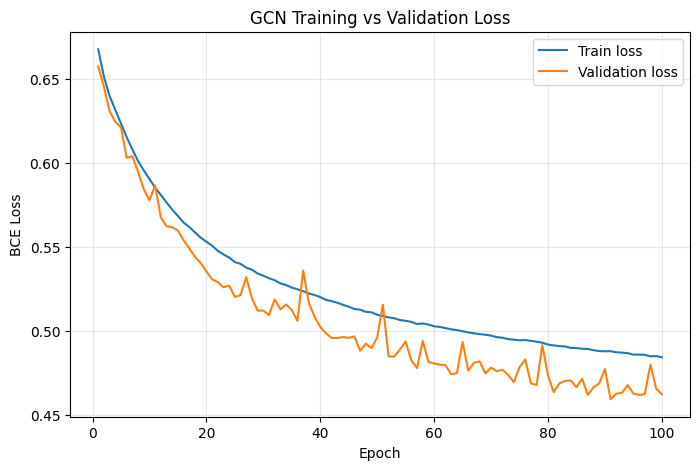

Saved loss curve plot to: /content/drive/MyDrive/4th year Coursework/Capstone Project/gcn_loss_curves.png


In [ ]:
#Plot loss curves
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Train loss')
plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.title('GCN Training vs Validation Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(GCN_LOSS_PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved loss curve plot to: {GCN_LOSS_PLOT_PATH}')

# **Step 5 — RAG pipeline (BioBERT + FAISS)**

This step constructs the retrieval-augmented generation (RAG) baseline for the dissertation. Instead of learning molecular structure like the GCN, it builds a text-driven system that represents each drug by encoding all its known interaction descriptions with BioBERT and storing those representations in a FAISS index. At inference time, the model answers a drug-drug interaction query by retrieving the most similar existing drug profiles and scoring the match based on their semantic similarity. In effect, this step creates a retrieval-based model that predicts interactions by searching and comparing biomedical knowledge rather than learning new representations from scratch.

In [ ]:
!pip install -q transformers faiss-cpu torch pandas tqdm


MERGED_CSV_PATH = f'{BASE_PATH}/ddi_interactions_with_smiles.csv'
TEST_CSV = f'{BASE_PATH}/ddi_test.csv'

RAG_EMBEDDINGS_PATH = f'{BASE_PATH}/rag_doc_embeddings.npy'
RAG_DRUG_IDS_PATH   = f'{BASE_PATH}/rag_doc_drug_ids.csv'
RAG_FAISS_INDEX_PATH = f'{BASE_PATH}/rag_faiss.index'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 115.4 MB/s eta 0:00:00


In [ ]:
#Build the per-drug corpus (concatenate all descriptions for that drug)
import pandas as pd

df = pd.read_csv(MERGED_CSV_PATH)

# Group by drug_id: join all descriptions where the drug is the "source" of the interaction
corpus_df = (
    df.groupby('drug_id')['description']
    .apply(lambda descs: ' '.join(descs.astype(str)))
    .reset_index()
    .rename(columns={'description': 'document'})
)
print(f'Corpus built for {len(corpus_df)} unique drugs')
corpus_df.head()

Corpus built for 3701 unique drugs


,drug_id,document
0,DB00006,Apixaban may increase the anticoagulant activi...
1,DB00014,Ivabradine may increase the QTc-prolonging act...
2,DB00027,The risk or severity of bleeding can be increa...
3,DB00035,The risk or severity of adverse effects can be...
4,DB00080,The serum concentration of Daptomycin can be i...


In [ ]:
#Embed each document with BioBERT [CLS] pooling
import torch
from transformers import AutoTokenizer, AutoModel
import numpy as np
from tqdm import tqdm

TOKENIZER = AutoTokenizer.from_pretrained('dmis-lab/biobert-base-cased-v1.2')
BIOBERT = AutoModel.from_pretrained('dmis-lab/biobert-base-cased-v1.2').to(DEVICE)
BIOBERT.eval()

@torch.no_grad()
def embed_text_cls(texts, batch_size=16, max_length=256):
    all_embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc='Embedding with BioBERT'):
        batch_texts = texts[i:i + batch_size]
        enc = TOKENIZER(batch_texts, padding=True, truncation=True,
                         max_length=max_length, return_tensors='pt').to(DEVICE)
        out = BIOBERT(**enc)
        cls_vecs = out.last_hidden_state[:, 0, :]  # [CLS] token, shape [B, 768]
        all_embeddings.append(cls_vecs.cpu().numpy())
    return np.vstack(all_embeddings)

doc_embeddings = embed_text_cls(corpus_df['document'].tolist())
print(f'Document embeddings shape: {doc_embeddings.shape}')  # [n_drugs, 768]

config.json:   0%|          | 0.00/1.11k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  436MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  436MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding with BioBERT:   0%|          | 0/232 [00:00<?, ?it/s]

Embedding with BioBERT:   0%|          | 1/232 [00:01<

Document embeddings shape: (3701, 768)


In [ ]:
#Build FAISS flat L2 index, save index + embeddings + id map to Drive
import faiss

dim = doc_embeddings.shape[1]  # 768
index = faiss.IndexFlatL2(dim)
index.add(doc_embeddings.astype('float32'))

faiss.write_index(index, RAG_FAISS_INDEX_PATH)
np.save(RAG_EMBEDDINGS_PATH, doc_embeddings)
corpus_df[['drug_id']].to_csv(RAG_DRUG_IDS_PATH, index=False)

print(f'FAISS index size: {index.ntotal} vectors')
print(f'Saved index to {RAG_FAISS_INDEX_PATH}')
print(f'Saved embeddings to {RAG_EMBEDDINGS_PATH}')
print(f'Saved drug-id map to {RAG_DRUG_IDS_PATH}')

FAISS index size: 3701 vectors
Saved index to /content/drive/MyDrive/4th year Coursework/Capstone Project/rag_faiss.index
Saved embeddings to /content/drive/MyDrive/4th year Coursework/Capstone Project/rag_doc_embeddings.npy
Saved drug-id map to /content/drive/MyDrive/4th year Coursework/Capstone Project/rag_doc_drug_ids.csv


In [ ]:
#Inference: query with a drug pair, retrieve top-k, weighted cosine similarity, threshold
drug_id_list = corpus_df['drug_id'].tolist()  # index position -> drug_id
drug_id_to_doc = dict(zip(corpus_df['drug_id'], corpus_df['document']))

def cosine_sim(a, b):
    a = a / (np.linalg.norm(a) + 1e-8)
    b = b / (np.linalg.norm(b) + 1e-8)
    return float(np.dot(a, b))

def rag_predict_pair(drug_a_id, drug_b_id, top_k=5):
    """
    Encodes a query built from both drugs' known text, retrieves top-k nearest
    documents from the FAISS index, and scores the pair via a distance-weighted
    average cosine similarity between the query and each retrieved neighbour,
    passed through a sigmoid and thresholded at 0.5.
    """
    query_text_parts = []
    for d in (drug_a_id, drug_b_id):
        if d in drug_id_to_doc:
            query_text_parts.append(drug_id_to_doc[d])
    query_text = ' '.join(query_text_parts) if query_text_parts else f'{drug_a_id} {drug_b_id}'

    query_vec = embed_text_cls([query_text], batch_size=1)[0]  # [768]

    distances, neighbor_idx = index.search(query_vec.reshape(1, -1).astype('float32'), top_k)
    distances, neighbor_idx = distances[0], neighbor_idx[0]

    # Weighted cosine similarity: weight each neighbour's cosine sim by inverse L2 distance
    weights = 1.0 / (distances + 1e-6)
    weights = weights / weights.sum()

    sims = []
    for ni in neighbor_idx:
        neighbor_vec = doc_embeddings[ni]
        sims.append(cosine_sim(query_vec, neighbor_vec))
    weighted_score = float(np.sum(np.array(sims) * weights))

    prob = 1 / (1 + np.exp(-weighted_score))
    pred_label = int(prob >= 0.5)
    return pred_label, prob

# Quick smoke test on the first test-set pair
test_df_preview = pd.read_csv(TEST_CSV).iloc[0]
pred, prob = rag_predict_pair(test_df_preview['drug_id'], test_df_preview['interacting_drug_id'])
print(f'Example prediction: label={pred}, prob={prob:.4f}')

Embedding with BioBERT: 100%|██████████| 1/1 [00:00<00:00,  5.43it/s]

Example prediction: label=1, prob=0.7311


WHY build the query from BOTH drugs' documents:
    The prediction is about the pair, not either drug alone. The query must
    represent both drugs’ pharmacological context together; otherwise retrieval
    would only ever return neighbours relevant to one drug at a time.

WHY use two different metrics (L2 for retrieval, cosine for scoring):
    FAISS IndexFlatL2 retrieves neighbours ranked by L2 distance, that decides
    who gets returned and how each neighbour is weighted. Cosine similarity is
    then computed separately and is the actual value being averaged into the
    final score. The closer the neighbour (smaller L2 distance), the higher its
    weight in the cosine‑similarity average. This weighting is a design choice;
    a uniform top‑k average is an equally valid alternative and should be noted
    as such in the methodology.


# **Step 6 — Evaluation**

This step performs the final evaluation of both models. The GCN and the RAG pipeline are run on the exact same held-out test set, producing directly comparable probability outputs and predicted labels. Their performance is then measured using a shared suite of metrics, Accuracy, F1, AUROC, Precision, and Recall, all computed from the same sklearn functions to ensure no drift in definitions or thresholds. Finally, the step generates the core visualisations for the Results chapter: side-by-side confusion matrices, overlaid ROC curves, overlaid precision-recall curves, and a grouped bar chart summarising the metrics. Together, these outputs provide a fair, symmetric, and interpretable comparison of the two architectures.

In [ ]:

!pip install -q scikit-learn matplotlib seaborn pandas tqdm


CONF_MATRIX_PLOT_PATH = f'{BASE_PATH}/confusion_matrices.png'
ROC_PLOT_PATH = f'{BASE_PATH}/roc_curves.png'
PR_PLOT_PATH = f'{BASE_PATH}/pr_curves.png'
BAR_CHART_PATH = f'{BASE_PATH}/metric_comparison_bar.png'
METRICS_CSV_PATH = f'{BASE_PATH}/model_comparison_metrics.csv'

In [ ]:
# Get predictions from both models on the test set
# Assumes: 'model' (trained DDIGCN), 'test_loader'/'test_dataset' from Step 4,
# and 'doc_embeddings', 'drug_id_list', 'index' from Step 5 are in scope.
import numpy as np
import pandas as pd
import torch

test_df = pd.read_csv(TEST_CSV).reset_index(drop=True)

# GCN predictions
gcn_probs, gcn_labels = [], []
test_loader_eval = DataLoader(test_dataset, batch_size=64, shuffle=False, collate_fn=pair_collate)
model.eval()
with torch.no_grad():
    for batch1, batch2, labels in test_loader_eval:
        batch1, batch2 = batch1.to(DEVICE), batch2.to(DEVICE)
        probs = model(batch1, batch2).cpu().numpy()
        gcn_probs.extend(probs.tolist())
        gcn_labels.extend(labels.numpy().tolist())

gcn_probs = np.array(gcn_probs)
gcn_labels = np.array(gcn_labels)
gcn_preds = (gcn_probs >= 0.5).astype(int)


# RAG predictions (no BioBERT calls, reuses Step 5's saved embeddings)
pairs = list(zip(test_df['drug_id'], test_df['interacting_drug_id']))


drug_id_to_row = {d: i for i, d in enumerate(drug_id_list)}

TOP_K = 5

def build_query_vec(a, b):
    vecs = [doc_embeddings[drug_id_to_row[d]] for d in (a, b) if d in drug_id_to_row]
    if not vecs:
        return np.zeros(doc_embeddings.shape[1], dtype='float32')
    return np.mean(vecs, axis=0)

# Build all query vectors at once — this replaces every BioBERT call
query_vecs = np.stack([build_query_vec(a, b) for a, b in pairs]).astype('float32')  # [N, 768]

# One FAISS search for the entire test set
distances, neighbor_idx = index.search(query_vecs, TOP_K)  # [N, k]

weights = 1.0 / (distances + 1e-6)
weights = weights / weights.sum(axis=1, keepdims=True)

neighbor_vecs = doc_embeddings[neighbor_idx]  # [N, k, 768]
q_norm = query_vecs / (np.linalg.norm(query_vecs, axis=1, keepdims=True) + 1e-8)
n_norm = neighbor_vecs / (np.linalg.norm(neighbor_vecs, axis=2, keepdims=True) + 1e-8)
sims = np.einsum('nd,nkd->nk', q_norm, n_norm)

weighted_scores = (sims * weights).sum(axis=1)
rag_probs = 1 / (1 + np.exp(-weighted_scores))
rag_preds = (rag_probs >= 0.5).astype(int)
rag_labels = test_df['label'].values

print(f'GCN predictions: {len(gcn_preds)} | RAG predictions: {len(rag_preds)}')

GCN predictions: 236311 | RAG predictions: 236374


In [ ]:
# Metrics table
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, precision_score, recall_score

def compute_metrics(y_true, y_pred, y_prob):
    return {
        'F1-score': f1_score(y_true, y_pred),
        'Accuracy': accuracy_score(y_true, y_pred),
        'AUROC': roc_auc_score(y_true, y_prob),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
    }

gcn_metrics = compute_metrics(gcn_labels, gcn_preds, gcn_probs)
rag_metrics = compute_metrics(rag_labels, rag_preds, rag_probs)

metrics_df = pd.DataFrame([gcn_metrics, rag_metrics], index=['GCN', 'RAG'])
metrics_df.to_csv(METRICS_CSV_PATH)
print(metrics_df)

     F1-score  Accuracy     AUROC  Precision    Recall
GCN  0.795970  0.787708  0.868730   0.766316  0.828012
RAG  0.666667  0.500000  0.615153   0.500000  1.000000


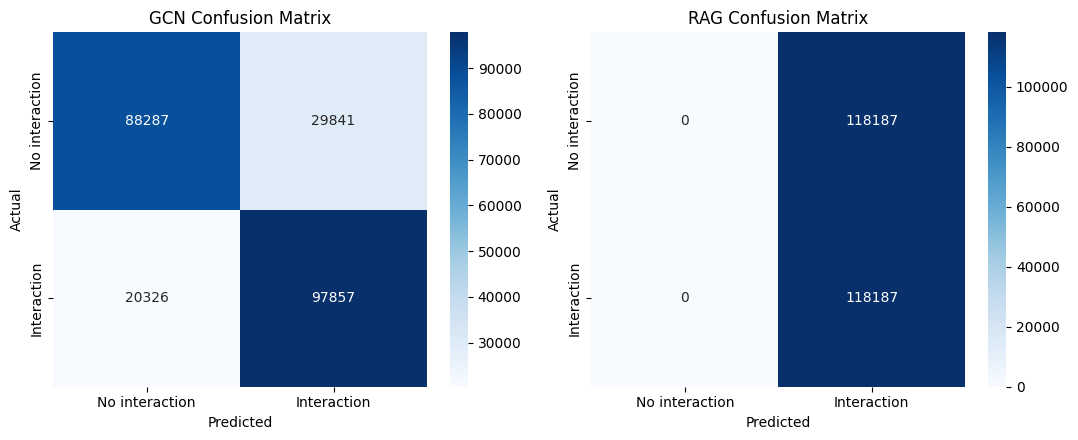

In [ ]:
#Side-by-side confusion matrices
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, y_true, y_pred) in zip(
    axes,
    [('GCN', gcn_labels, gcn_preds), ('RAG', rag_labels, rag_preds)]
):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No interaction', 'Interaction'],
                yticklabels=['No interaction', 'Interaction'])
    ax.set_title(f'{name} Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig(CONF_MATRIX_PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()

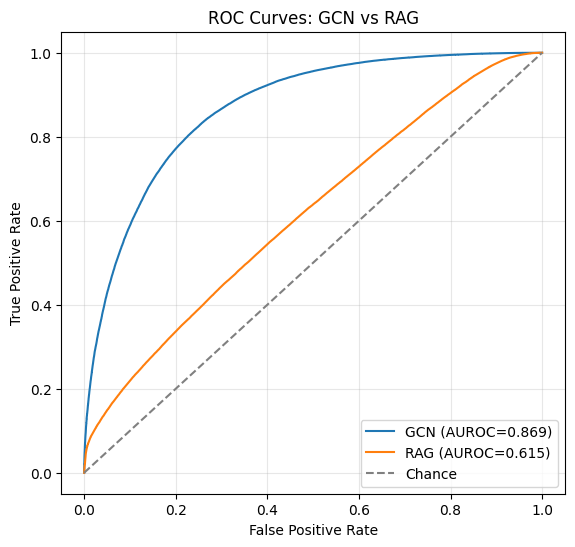

In [ ]:
# ROC curves, both models on same axes
from sklearn.metrics import roc_curve

fpr_gcn, tpr_gcn, _ = roc_curve(gcn_labels, gcn_probs)
fpr_rag, tpr_rag, _ = roc_curve(rag_labels, rag_probs)

plt.figure(figsize=(6.5, 6))
plt.plot(fpr_gcn, tpr_gcn, label=f"GCN (AUROC={gcn_metrics['AUROC']:.3f})")
plt.plot(fpr_rag, tpr_rag, label=f"RAG (AUROC={rag_metrics['AUROC']:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: GCN vs RAG')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(ROC_PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()

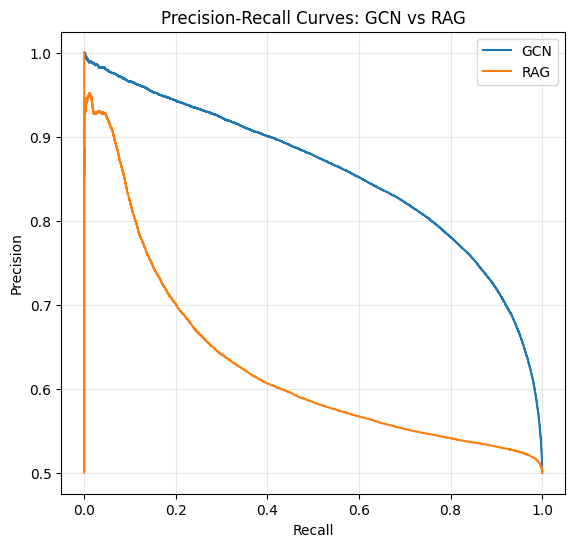

In [ ]:
#  Precision-Recall curves, both models on same axes
from sklearn.metrics import precision_recall_curve

prec_gcn, rec_gcn, _ = precision_recall_curve(gcn_labels, gcn_probs)
prec_rag, rec_rag, _ = precision_recall_curve(rag_labels, rag_probs)

plt.figure(figsize=(6.5, 6))
plt.plot(rec_gcn, prec_gcn, label='GCN')
plt.plot(rec_rag, prec_rag, label='RAG')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves: GCN vs RAG')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(PR_PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()

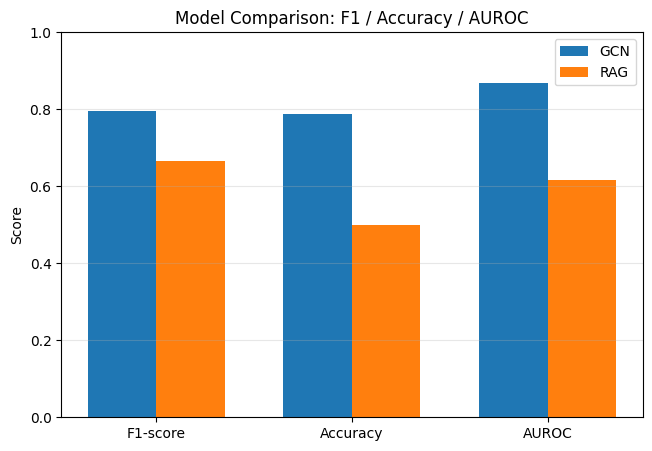

In [ ]:
#  Grouped bar chart: F1, Accuracy, AUROC across both models
compare_cols = ['F1-score', 'Accuracy', 'AUROC']
x = np.arange(len(compare_cols))
width = 0.35

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.bar(x - width/2, metrics_df.loc['GCN', compare_cols], width, label='GCN')
ax.bar(x + width/2, metrics_df.loc['RAG', compare_cols], width, label='RAG')
ax.set_xticks(x)
ax.set_xticklabels(compare_cols)
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.set_title('Model Comparison: F1 / Accuracy / AUROC')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.savefig(BAR_CHART_PATH, dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Explainability case studies: RAG's evidence trail vs GCN's opaque prediction
import textwrap

N_EXAMPLES = 5
SNIPPET_LEN = 200


sample_indices = np.random.RandomState(42).choice(len(test_df), size=N_EXAMPLES, replace=False)

for idx in sample_indices:
    row = test_df.iloc[idx]
    a, b = row['drug_id'], row['interacting_drug_id']
    true_label = row['label']

    print('=' * 80)
    print(f'Pair: {a} + {b}   |   True label: {"INTERACTS" if true_label == 1 else "NO INTERACTION"}')
    print('-' * 80)

    # GCN's side: just a probability, no supporting evidence
    print(f'[GCN]  Predicted probability: {gcn_probs[idx]:.3f}  ->  '
          f'{"INTERACTS" if gcn_preds[idx] == 1 else "NO INTERACTION"}')
    print('       No retrievable evidence trail — this prediction comes from a learned')
    print('       256-dimensional embedding with no direct correspondence to readable text.')

    # RAG's side: show exactly which documents it retrieved and how heavily each counted
    query_vec = build_query_vec(a, b).reshape(1, -1).astype('float32')
    distances, neighbor_idx = index.search(query_vec, TOP_K)
    distances, neighbor_idx = distances[0], neighbor_idx[0]
    weights = 1.0 / (distances + 1e-6)
    weights = weights / weights.sum()

    print(f'\n[RAG]  Predicted probability: {rag_probs[idx]:.3f}  ->  '
          f'{"INTERACTS" if rag_preds[idx] == 1 else "NO INTERACTION"}')
    print('       Evidence retrieved (closer match = more influence on the final score):')
    for rank, (ni, dist, w) in enumerate(zip(neighbor_idx, distances, weights), start=1):
        retrieved_drug_id = drug_id_list[ni]
        snippet = corpus_df.loc[corpus_df['drug_id'] == retrieved_drug_id, 'document'].values[0]
        snippet = textwrap.shorten(snippet, width=SNIPPET_LEN, placeholder='...')
        print(f'         {rank}. Drug {retrieved_drug_id} (weight={w:.2f}, distance={dist:.2f}): "{snippet}"')
    print()

Pair: DB00591 + DB13848   |   True label: NO INTERACTION
--------------------------------------------------------------------------------
[GCN]  Predicted probability: 0.397  ->  NO INTERACTION
       No retrievable evidence trail — this prediction comes from a learned
       256-dimensional embedding with no direct correspondence to readable text.

[RAG]  Predicted probability: 0.725  ->  INTERACTS
       Evidence retrieved (closer match = more influence on the final score):
         1. Drug DB00591 (weight=0.21, distance=13.84): "The risk or severity of adverse effects can be increased when Phenylalanine is combined with Fluocinolone acetonide. Fluocinolone acetonide may increase the immunosuppressive activities of..."
         2. Drug DB13848 (weight=0.21, distance=13.84): "The bioavailability of Fluorodopa (18F) can be increased when combined with Carbidopa. The bioavailability of Fluorodopa (18F) can be increased when combined with Methyldopa. The bioavailability of..."
         3